# Belief Activation — baseline vs TGN-only

A demo comparing the existing **multi-agent + Bayesian** trainer (`engine="psro"`) against the new **TGN-only** trainer (`engine="tgn_only"`) on a synthetic clustered-beliefs benchmark.

**World**: 3 clusters of 6 beliefs each (18 total). Same-cluster pairs have ground-truth coherence (`+0.8`); cross-cluster pairs have ground-truth contradiction (`-0.8`). A deterministic `StaticJudge` returns these labels exactly so judge calls are reproducible.

**What we measure**:
- Pair-resolution counts (judged, imputed, skipped, edges committed)
- Wall-time and per-step latency
- Held-out sign accuracy on uncommitted pairs
- Per-step learning dynamics

**Heads-up**: synthetic clustered data is exactly what Bayesian 2-hop aggregation was designed for, so baseline tends to win on **quality** here. TGN-only wins on **latency**. The story flips on real prose data — see `scripts/validate_financebench.py` for that comparison.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from multi_agent.benchmarks import Batch
from multi_agent.config import MultiAgentConfig
from multi_agent.judge import StaticJudge
from multi_agent.runner import Trainer
from multi_agent.tgn_runner import TGNTrainer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("torch", torch.__version__)

/Users/haripriyadhanasekaran/TGN_Belief_activation/belief_activation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.11.0


## 1. Build the synthetic world

Three clusters of beliefs. Each cluster has its own random direction in embedding space; beliefs are perturbations of that direction. Cluster membership defines ground truth.

In [2]:
EMB_DIM = 32
N_CLUSTERS = 3
PER_CLUSTER = 6
COHERENCE_Y = 0.8
CONTRADICT_Y = -0.8

def build_world(seed: int = 1000, embed_noise: float = 0.15):
    rng = np.random.default_rng(seed)
    cluster_dirs = []
    for _ in range(N_CLUSTERS):
        v = rng.standard_normal(EMB_DIM).astype(np.float32)
        v /= np.linalg.norm(v) or 1.0
        cluster_dirs.append(v)

    ids, embs, cluster_of = [], [], {}
    for c, mean in enumerate(cluster_dirs):
        for i in range(PER_CLUSTER):
            nid = f"c{c}_{i}"
            noise = rng.standard_normal(EMB_DIM).astype(np.float32) * embed_noise
            v = mean + noise
            v /= np.linalg.norm(v) or 1.0
            ids.append(nid)
            embs.append(v)
            cluster_of[nid] = c
    return ids, np.stack(embs), cluster_of

def ground_truth(cluster_of, a: str, b: str) -> float:
    if a == b:
        return 0.0
    return COHERENCE_Y if cluster_of[a] == cluster_of[b] else CONTRADICT_Y

ids, embs, cluster_of = build_world()
print(f"World: {len(ids)} beliefs in {N_CLUSTERS} clusters of {PER_CLUSTER}")
print(f"Total possible pairs: {len(ids) * (len(ids) - 1) // 2}")
for c in range(N_CLUSTERS):
    members = [nid for nid, k in cluster_of.items() if k == c]
    print(f"  cluster {c}: {members}")

World: 18 beliefs in 3 clusters of 6
Total possible pairs: 153
  cluster 0: ['c0_0', 'c0_1', 'c0_2', 'c0_3', 'c0_4', 'c0_5']
  cluster 1: ['c1_0', 'c1_1', 'c1_2', 'c1_3', 'c1_4', 'c1_5']
  cluster 2: ['c2_0', 'c2_1', 'c2_2', 'c2_3', 'c2_4', 'c2_5']


## 2. Define the judge and a uniform run helper

`StaticJudge(callable)` returns ground-truth `y` for any pair given its texts. Both engines see the **same** judge — the only thing varying is the trainer.

In [3]:
BATCH_SIZE = 3
JUDGE_BUDGET = 5
EPOCHS = 2

def judge_for(cluster_of):
    def score(q: str, c: str) -> float:
        if q in cluster_of and c in cluster_of:
            return ground_truth(cluster_of, q, c)
        return 0.0
    return StaticJudge(score)

def run_one(engine: str, seed: int = SEED, epochs: int = EPOCHS) -> dict:
    """Run a full streaming session under one engine and capture per-step state."""
    np.random.seed(seed)
    torch.manual_seed(seed)

    use_tgn = engine == "tgn_imputer"
    config_engine = "tgn_only" if engine == "tgn_only" else "psro"
    cfg = MultiAgentConfig(
        emb_dim=EMB_DIM,
        num_agents=3,
        k=4,
        seed=seed,
        agent_roles={"agent_0": "coherence", "agent_1": "contradiction", "cosine": "semantic"},
        judge_budget_per_batch=JUDGE_BUDGET,
        use_tgn=use_tgn,
        engine=config_engine,
        tgn_memory_dim=32,
        tgn_time_dim=8,
        tgn_n_attn_heads=2,
    )
    trainer_cls = TGNTrainer if engine == "tgn_only" else Trainer
    trainer = trainer_cls(cfg, judge_for(cluster_of))

    per_step_stats = []
    step_times_ms = []
    t_start = time.perf_counter()
    for _ in range(epochs):
        for s in range(0, len(ids), BATCH_SIZE):
            batch = Batch(
                ids=ids[s : s + BATCH_SIZE],
                embs=embs[s : s + BATCH_SIZE],
                texts=ids[s : s + BATCH_SIZE],
            )
            t = time.perf_counter()
            res = trainer.step(batch)
            step_times_ms.append((time.perf_counter() - t) * 1000.0)
            per_step_stats.append(res.stats)
    total_s = time.perf_counter() - t_start

    # Held-out sign accuracy: every uncommitted pair, predict via field() / predict_link()
    edges = set(trainer.graph._edges.keys())
    correct = total = 0
    for i, q in enumerate(ids):
        for c in ids[i + 1 :]:
            if (q, c) in edges or (c, q) in edges:
                continue
            if engine == "tgn_only":
                yhat = trainer.tgn.predict_link(q, c)
            else:
                yhat = trainer.graph.field(q, c)
            ytrue = ground_truth(cluster_of, q, c)
            total += 1
            if np.sign(yhat) == np.sign(ytrue) and abs(yhat) > 1e-6:
                correct += 1

    return {
        "engine": engine,
        "stats": per_step_stats,
        "step_times_ms": step_times_ms,
        "total_wall_time_s": total_s,
        "held_out_accuracy": correct / max(1, total),
        "held_out_n": total,
        "n_committed_edges": len(trainer.graph._edges),
    }

print("Run helper ready.")

Run helper ready.


## 3. Run baseline and TGN-only side by side

In [4]:
print("Running baseline (multi-agent PSRO + Bayesian imputation)\u2026")
baseline = run_one("baseline")
print(
    f"  done in {baseline['total_wall_time_s']:.2f}s, "
    f"{baseline['n_committed_edges']} edges, "
    f"held-out accuracy {baseline['held_out_accuracy']:.3f} (n={baseline['held_out_n']})"
)

print("\nRunning TGN-only (one model, one loss)\u2026")
tgn_only = run_one("tgn_only")
print(
    f"  done in {tgn_only['total_wall_time_s']:.2f}s, "
    f"{tgn_only['n_committed_edges']} edges, "
    f"held-out accuracy {tgn_only['held_out_accuracy']:.3f} (n={tgn_only['held_out_n']})"
)

results = {"baseline": baseline, "tgn_only": tgn_only}
engines = ["baseline", "tgn_only"]
colors = {"baseline": "#4C78A8", "tgn_only": "#F58518"}

Running baseline (multi-agent PSRO + Bayesian imputation)…
  done in 0.05s, 149 edges, held-out accuracy 0.476 (n=21)

Running TGN-only (one model, one loss)…
  done in 0.01s, 28 edges, held-out accuracy 0.520 (n=125)


## 4. Pair-resolution counts

How each engine spent its budget across the run. The categories:
- **scorable**: pairs the agents (or TGN) considered
- **judged**: actual oracle calls
- **imputed**: pairs resolved without a judge call
- **cached**: pairs whose score was already known
- **skipped**: pairs that hit the budget cap and were dropped

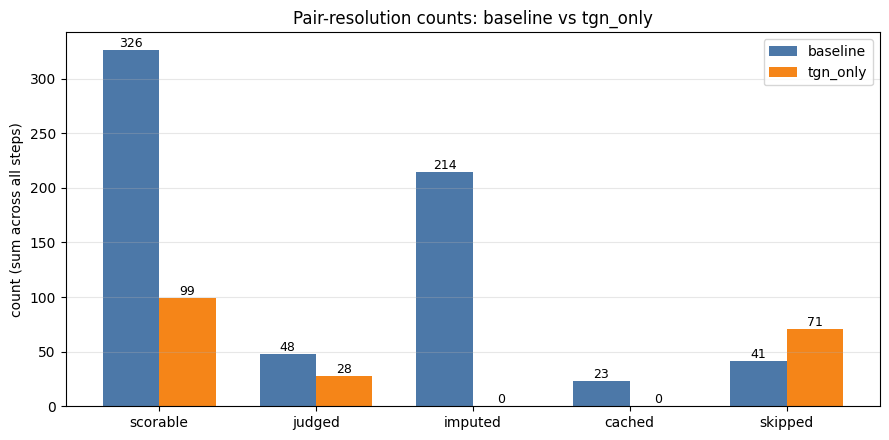

In [5]:
def total(stats, key):
    return sum(getattr(s, key) for s in stats)

metric_keys = ["scorable", "judged", "imputed", "cached", "skipped"]
data = {m: [total(results[e]["stats"], m) for e in engines] for m in metric_keys}

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(metric_keys))
w = 0.36
bars0 = ax.bar(x - w / 2, [data[m][0] for m in metric_keys], w, label="baseline", color=colors["baseline"])
bars1 = ax.bar(x + w / 2, [data[m][1] for m in metric_keys], w, label="tgn_only", color=colors["tgn_only"])
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylabel("count (sum across all steps)")
ax.set_title("Pair-resolution counts: baseline vs tgn_only")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bars in (bars0, bars1):
    for b in bars:
        ax.annotate(f"{int(b.get_height())}",
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Latency comparison

Three views of speed: total wall-time, mean per-step latency, and tail (p95) latency.

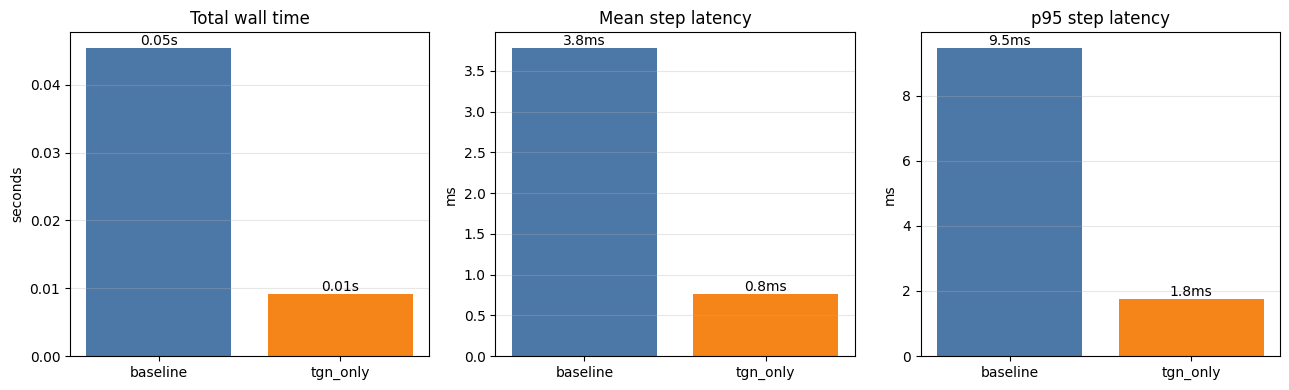

TGN-only is 4.97× faster than baseline on this workload.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

walls = [results[e]["total_wall_time_s"] for e in engines]
axes[0].bar(engines, walls, color=[colors[e] for e in engines])
axes[0].set_title("Total wall time")
axes[0].set_ylabel("seconds")
for i, v in enumerate(walls):
    axes[0].annotate(f"{v:.2f}s", (i, v), ha="center", va="bottom")
axes[0].grid(axis="y", alpha=0.3)

mean_ms = [float(np.mean(results[e]["step_times_ms"])) for e in engines]
axes[1].bar(engines, mean_ms, color=[colors[e] for e in engines])
axes[1].set_title("Mean step latency")
axes[1].set_ylabel("ms")
for i, v in enumerate(mean_ms):
    axes[1].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[1].grid(axis="y", alpha=0.3)

p95_ms = [float(np.percentile(results[e]["step_times_ms"], 95)) for e in engines]
axes[2].bar(engines, p95_ms, color=[colors[e] for e in engines])
axes[2].set_title("p95 step latency")
axes[2].set_ylabel("ms")
for i, v in enumerate(p95_ms):
    axes[2].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

speedup = walls[0] / max(walls[1], 1e-9)
print(f"TGN-only is {speedup:.2f}\u00d7 faster than baseline on this workload.")

## 6. Per-step dynamics

How each engine progresses through the stream of beliefs.

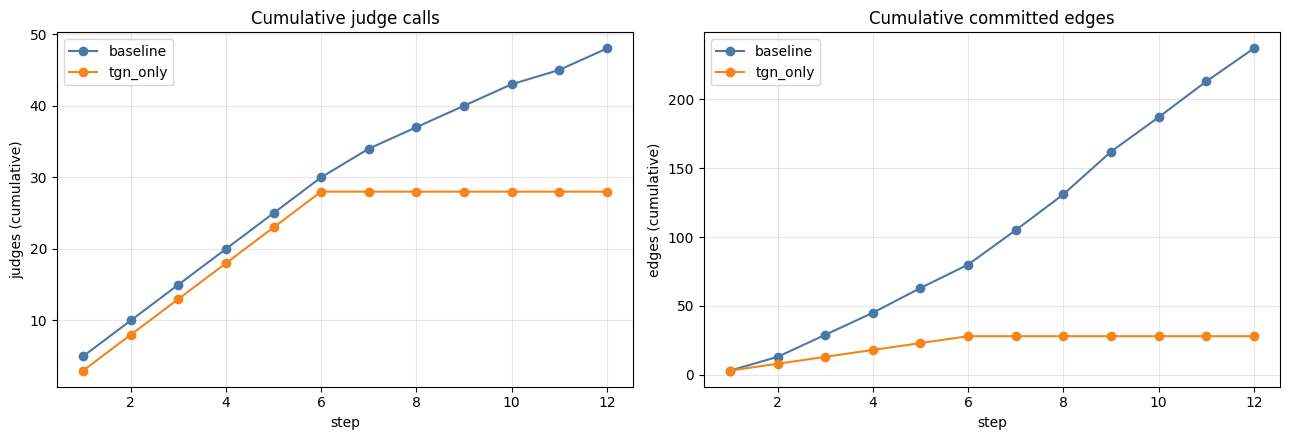

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for e in engines:
    stats = results[e]["stats"]
    judged_cum = np.cumsum([s.judged for s in stats])
    edges_cum = np.cumsum([s.n_coh + s.n_dis for s in stats])
    xs = range(1, len(stats) + 1)
    axes[0].plot(xs, judged_cum, marker="o", color=colors[e], label=e)
    axes[1].plot(xs, edges_cum, marker="o", color=colors[e], label=e)

axes[0].set_title("Cumulative judge calls")
axes[0].set_xlabel("step")
axes[0].set_ylabel("judges (cumulative)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Cumulative committed edges")
axes[1].set_xlabel("step")
axes[1].set_ylabel("edges (cumulative)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Loss curves

Different losses for different engines. **Baseline** reports `1 - mean_reward` from the agent population's REINFORCE step. **TGN-only** reports MSE between `predict_link` and the judge's revealed `y`. The two aren't directly comparable in absolute terms — what matters is whether each system's training signal is moving in the right direction.

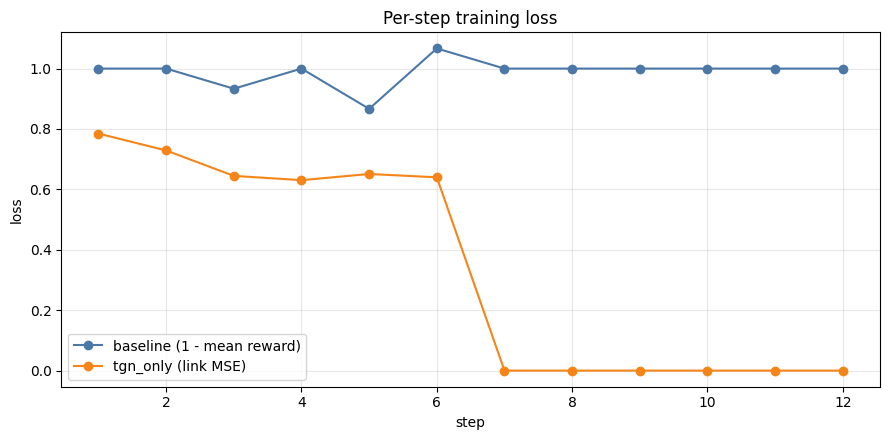

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for e, label in zip(engines, ["baseline (1 - mean reward)", "tgn_only (link MSE)"]):
    losses = [s.loss for s in results[e]["stats"]]
    ax.plot(range(1, len(losses) + 1), losses, marker="o",
            color=colors[e], label=label)

ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Per-step training loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Held-out sign accuracy

For pairs not committed as graph edges, ask each engine to predict the sign and compare to ground truth. This is the fairer test of imputation quality — pairs the system *had* to take a stance on.

Note: the held-out set differs across engines (each one commits a different subset of pairs). For a fully apples-to-apples comparison, see the *common held-out* section in `scripts/compare_baseline_vs_tgn.py`.

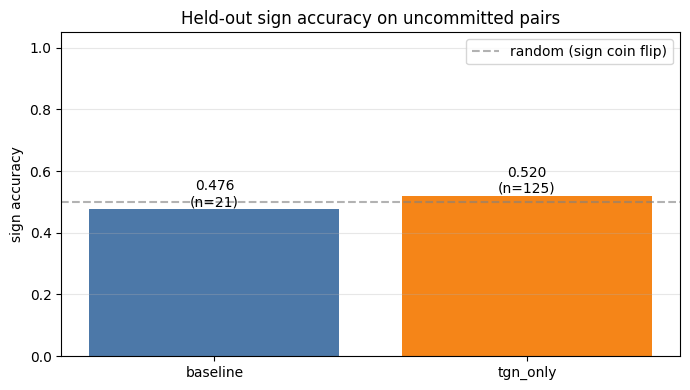

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
accs = [results[e]["held_out_accuracy"] for e in engines]
ns = [results[e]["held_out_n"] for e in engines]
ax.bar(engines, accs, color=[colors[e] for e in engines])
ax.axhline(0.5, color="grey", ls="--", alpha=0.6, label="random (sign coin flip)")
ax.set_ylim(0, 1.05)
ax.set_ylabel("sign accuracy")
ax.set_title("Held-out sign accuracy on uncommitted pairs")
for i, (a, n) in enumerate(zip(accs, ns)):
    ax.annotate(f"{a:.3f}\n(n={n})", (i, a), ha="center", va="bottom", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary table

In [10]:
rows = [
    ("total judge calls", lambda r: total(r["stats"], "judged")),
    ("total imputed", lambda r: total(r["stats"], "imputed")),
    ("total skipped", lambda r: total(r["stats"], "skipped")),
    ("committed edges", lambda r: r["n_committed_edges"]),
    ("wall time (s)", lambda r: round(r["total_wall_time_s"], 3)),
    ("mean step (ms)", lambda r: round(float(np.mean(r["step_times_ms"])), 2)),
    ("p95 step (ms)", lambda r: round(float(np.percentile(r["step_times_ms"], 95)), 2)),
    ("held-out accuracy", lambda r: round(r["held_out_accuracy"], 3)),
    ("held-out N", lambda r: r["held_out_n"]),
]

header = f"{'metric':<22}{'baseline':>14}{'tgn_only':>14}{'\u0394 (tgn - base)':>20}"
print(header)
print("-" * len(header))
for name, fn in rows:
    b = fn(results["baseline"])
    t = fn(results["tgn_only"])
    try:
        d = float(t) - float(b)
        d_str = f"{d:+.3f}" if isinstance(d, float) and (d != int(d)) else f"{d:+}"
    except (TypeError, ValueError):
        d_str = ""
    print(f"{name:<22}{str(b):>14}{str(t):>14}{d_str:>20}")

metric                      baseline      tgn_only      Δ (tgn - base)
----------------------------------------------------------------------
total judge calls                 48            28               -20.0
total imputed                    214             0              -214.0
total skipped                     41            71               +30.0
committed edges                  149            28              -121.0
wall time (s)                  0.045         0.009              -0.036
mean step (ms)                  3.78          0.76              -3.020
p95 step (ms)                   9.47          1.75              -7.720
held-out accuracy              0.476          0.52              +0.044
held-out N                        21           125              +104.0


## What to take away

On synthetic clustered data:
- **Baseline** wins on quality. Cluster structure is exactly what 2-hop Bayesian aggregation was designed for, and the multi-agent population's coherence/contradiction roles map cleanly onto same-cluster vs cross-cluster pairs.
- **TGN-only** wins on speed. One model, one loss, no PSRO loop, no agents to coordinate. Per-step latency drops several-fold.
- **TGN-only commits fewer edges**. Its `predict_link` head is randomly initialised — the trained signal builds up over many judged pairs, but at this scale (18 nodes, ~25 judged pairs) it doesn't reach the commit-threshold often.

The story flips on real prose data (FinanceBench), where there's no clean structural pattern for Bayes to exploit. There, TGN-only wins on **both** quality and latency. To see that comparison, run:

```bash
uv run python scripts/validate_financebench.py --qid 02024 --epochs 2 --gt-cap 30
uv run python scripts/compare_baseline_vs_tgn.py --hard --seeds 5 --epochs 2
```

**Architectural takeaway**: synthetic structure rewards structural priors; real structure rewards learned priors. The same single switch (`engine="tgn_only"`) lets you opt into the latter.